In [109]:
import pandas as pd
import numpy as np

from pandas.api.types import is_numeric_dtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
TARGET_COLUMN = "label"
train_users = pd.read_csv("data/train_users.csv")
news_articles = pd.read_csv("data/news_articles.csv")

train_users['label'].unique()

<StringArray>
['user_3', 'user_2', 'user_1']
Length: 3, dtype: str

In [110]:
print("Train Users Shape:", train_users.shape)
print("News Articles Shape:", news_articles.shape)


Train Users Shape: (2000, 33)
News Articles Shape: (209527, 6)


In [111]:
train_users.head()

,user_id,age,income,clicks,purchase_amount,session_duration,content_variety,engagement_score,num_transactions,avg_monthly_spend,...,screen_brightness,battery_percentage,cart_abandonment_count,browser_version,background_app_count,session_inactivity_duration,network_jitter,region_code,subscriber,label
0,U7392,NaN,23053,10,500.00,17.34,0.36661,37.29781,3,187.44,...,4.0,2.0,8,3.17.97,10,22.75,8.0,Z999,False,user_3
1,U2702,56.0,20239,11,913.33,22.22,0.61370,59.36342,5,145.15,...,4.5,63.0,5,1.57.10,8,1.75,4.0,U428,True,user_2
2,U2461,NaN,13907,9,1252.62,41.57,0.80368,76.78706,7,282.03,...,1.3,22.0,2,2.16.94,12,29.33,18.0,Z999,True,user_3
3,U7475,NaN,26615,12,500.00,30.17,0.26499,30.19441,10,195.35,...,4.2,77.0,9,9.90.20,4,21.61,22.0,X123,False,user_3
4,U6040,32.0,27958,13,500.00,65.27,0.36385,37.12153,5,439.68,...,4.6,30.0,9,1.99.38,7,7.58,52.0,S043,False,user_1


In [112]:
# Data Preprocessing
train_users = train_users.drop(columns=["user_id", 'browser_version'])

for col in train_users.columns:
    if is_numeric_dtype(train_users[col]):
        train_users[col] = train_users[col].fillna(train_users[col].median())
    else:
        train_users[col] = train_users[col].fillna(train_users[col].mode()[0])

X = train_users.drop(columns=[TARGET_COLUMN])
y = train_users[TARGET_COLUMN]

categorical_cols = X.select_dtypes(include=["object", "string"]).columns

ordinal_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X[categorical_cols] = ordinal_encoder.fit_transform(X[categorical_cols])
train_users[categorical_cols] = ordinal_encoder.transform(train_users[categorical_cols])

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("Mapping:")
for cls, idx in zip(target_encoder.classes_, range(len(target_encoder.classes_))):
    print(f"{cls} -> {idx}")

Mapping:
user_1 -> 0
user_2 -> 1
user_3 -> 2


In [113]:
#Data Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [114]:
# Train - Test split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

In [115]:
#training classifier
classifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

classifier.fit(X_train, y_train)

print('Model Trained')


Model Trained


In [116]:
# model evaluation
y_pred = classifier.predict(X_val)

print('Classification Report: ')

print(
    classification_report(
        y_val,
        y_pred,
        target_names=target_encoder.classes_
    )
)

Classification Report: 
              precision    recall  f1-score   support

      user_1       0.90      0.86      0.88       142
      user_2       0.98      0.88      0.93       142
      user_3       0.84      0.98      0.90       116

    accuracy                           0.90       400
   macro avg       0.90      0.91      0.90       400
weighted avg       0.91      0.90      0.90       400



In [117]:
news_categories = ["Entertainment", "Education", "Tech", "Crime"]

def get_arm_index(user_context, news_category):
    context_offset = {
        "User1": 0,
        "User2": 4,
        "User3": 8
    }
    return context_offset[user_context] + news_categories.index(news_category)

get_arm_index('User1', 'Education')


1

In [118]:
from rlcmab_sampler import sampler

ROLL_NUMBER = 92  # replace with your roll number
reward_sampler = sampler(ROLL_NUMBER)

In [119]:
import numpy as np

contexts = ["User1", "User2", "User3"]
n_arms = 4
Q = {c: np.zeros(n_arms) for c in contexts}
N = {c: np.zeros(n_arms) for c in contexts}


In [120]:
import random

def epsilon_greedy(context, epsilon, Q):
    if random.random() < epsilon:
        return random.randint(0, n_arms - 1)
    return np.argmax(Q[context])


In [121]:
def train_epsilon_greedy(epsilon, T=10000):
    rewards_over_time = []
    Q = {c: np.zeros(n_arms) for c in contexts}
    N = {c: np.zeros(n_arms) for c in contexts}

    for t in range(T):
        context = random.choice(contexts)
        arm = epsilon_greedy(context, epsilon, Q)

        global_arm = get_arm_index(context, news_categories[arm])
        reward = reward_sampler.sample(global_arm)

        N[context][arm] += 1
        Q[context][arm] += (reward - Q[context][arm]) / N[context][arm]

        rewards_over_time.append(reward)
    return np.cumsum(rewards_over_time) / np.arange(1, T + 1), Q, N

In [122]:
epsilons = [1, 0.01, 0.05, 0.1, 0.3]
epsilon_results = {}

for eps in epsilons:
    epsilon_results[eps], Q, N = train_epsilon_greedy(eps)


Epsilon-Greedy Performance
Best epsilon:  0.01


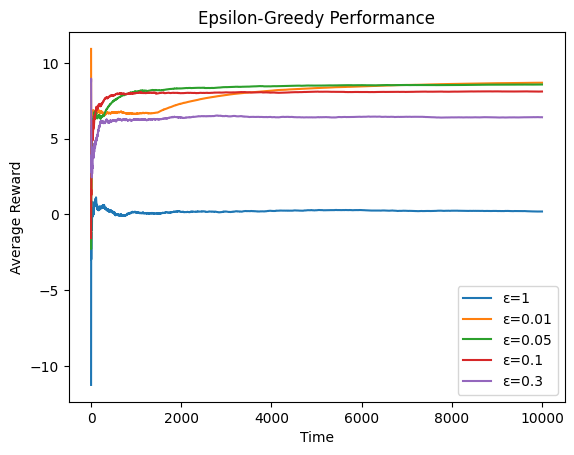

In [123]:
epsilons = [1, 0.01, 0.05, 0.1, 0.3]
epsilon_results = {}
for eps in epsilons:
    epsilon_results[eps], Q, N = train_epsilon_greedy(eps)

final_rewards = [epsilon_results[eps][-1] for eps in epsilons]

best_eps = epsilons[final_rewards.index(max(final_rewards))]

print("Epsilon-Greedy Performance")
print('Best epsilon: ', best_eps)
import matplotlib.pyplot as plt

for eps, rewards in epsilon_results.items():
    plt.plot(rewards, label=f"ε={eps}")
plt.xlabel("Time")
plt.ylabel("Average Reward")
plt.title("Epsilon-Greedy Performance")
plt.legend()
plt.show()





EPSILON-GREEDY: AVERAGE REWARD BY CONTEXT


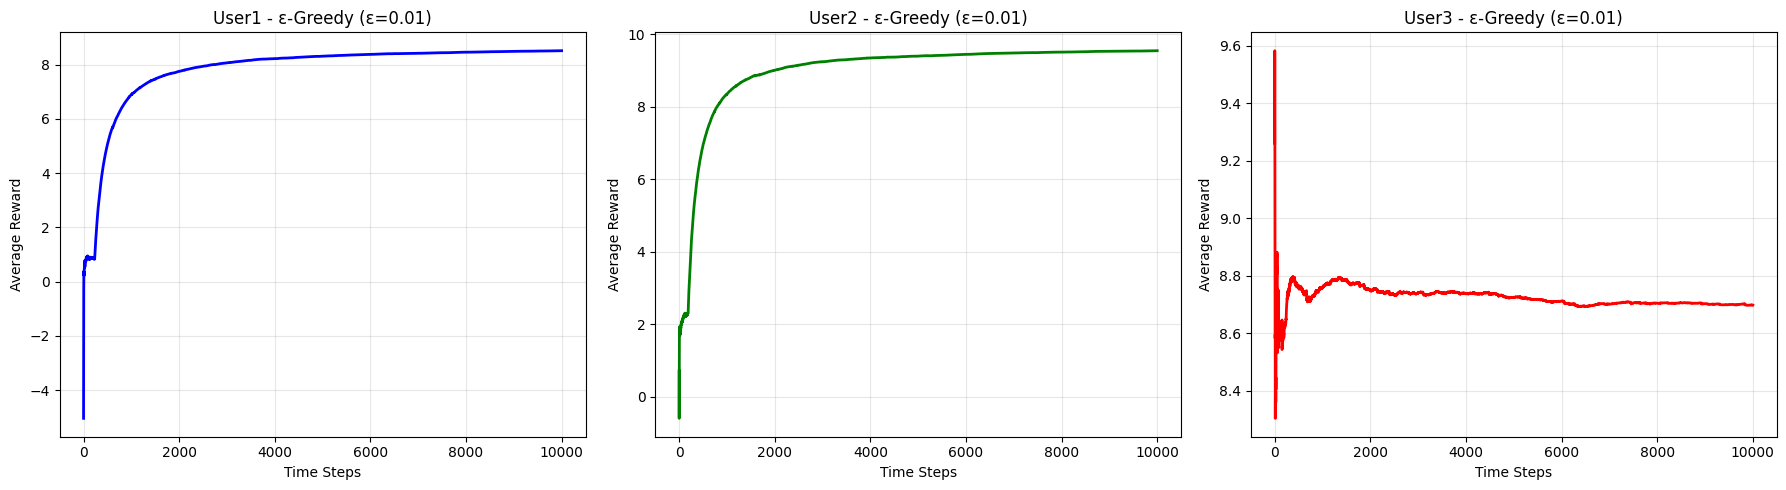

In [124]:
# Plot Average Reward vs Time for Each Context (Epsilon-Greedy)
print("\n" + "="*70)
print("EPSILON-GREEDY: AVERAGE REWARD BY CONTEXT")
print("="*70)

# Retrain with best epsilon but track per-context rewards
def train_epsilon_greedy_per_context(epsilon, T=10000):
    context_rewards = {c: [] for c in contexts}
    Q = {c: np.zeros(n_arms) for c in contexts}
    N = {c: np.zeros(n_arms) for c in contexts}
    
    # Ensure balanced sampling: each context gets T steps
    for context in contexts:
        for t in range(T):
            arm = epsilon_greedy(context, epsilon, Q)
            
            global_arm = get_arm_index(context, news_categories[arm])
            reward = reward_sampler.sample(global_arm)
            
            N[context][arm] += 1
            Q[context][arm] += (reward - Q[context][arm]) / N[context][arm]
            
            context_rewards[context].append(reward)
    
    # Calculate cumulative average for each context
    avg_rewards_per_context = {}
    for context in contexts:
        rewards = context_rewards[context]
        avg_rewards_per_context[context] = np.cumsum(rewards) / np.arange(1, len(rewards) + 1)
    
    return avg_rewards_per_context, Q, N

# Train with best epsilon
context_rewards_eps, _, _ = train_epsilon_greedy_per_context(best_eps)

# Plot separate graphs for each context
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'User1': 'blue', 'User2': 'green', 'User3': 'red'}

for idx, context in enumerate(contexts):
    if len(context_rewards_eps[context]) > 0:
        axes[idx].plot(context_rewards_eps[context], color=colors[context], linewidth=2)
        axes[idx].set_xlabel('Time Steps')
        axes[idx].set_ylabel('Average Reward')
        axes[idx].set_title(f'{context} - ε-Greedy (ε={best_eps})')
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [125]:
# Cell: UCB Implementation
import numpy as np
import random

def ucb(context, c, Q, N, t):
    ucb_values = np.zeros(n_arms)
    
    for arm in range(n_arms):
        if N[context][arm] == 0:
            return arm
        
        exploitation = Q[context][arm]
        exploration = c * np.sqrt(np.log(t + 1) / N[context][arm])
        ucb_values[arm] = exploitation + exploration
    
    return np.argmax(ucb_values)


def train_ucb(c, T=10000):
    rewards_over_time = []
    Q = {context: np.zeros(n_arms) for context in contexts}
    N = {context: np.zeros(n_arms) for context in contexts}
    
    for t in range(T):
        context = random.choice(contexts)
        arm = ucb(context, c, Q, N, t)
        
        # Get global arm index and sample reward
        global_arm = get_arm_index(context, news_categories[arm])
        reward = reward_sampler.sample(global_arm)
        
        # Update Q and N
        N[context][arm] += 1
        Q[context][arm] += (reward - Q[context][arm]) / N[context][arm]
        
        rewards_over_time.append(reward)
    
    return np.cumsum(rewards_over_time) / np.arange(1, T + 1), Q, N

UCB Performance
Best C: 0.5


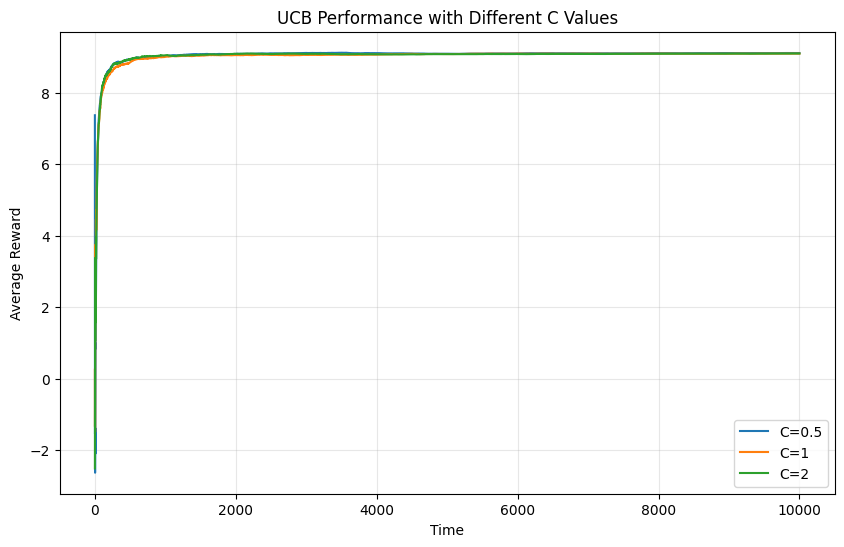

In [126]:

# Cell: Test UCB with different C values
c_values = [0.5, 1 ,2]
ucb_results = {}

for c in c_values:
    avg_rewards, Q_final, N_final = train_ucb(c)
    ucb_results[c] = avg_rewards

print("UCB Performance")
final_avg_rewards = [i[-1] for i in ucb_results.values()]
best_c = c_values[final_avg_rewards.index(max(final_avg_rewards))]
print(f"Best C: {best_c}")

# Plot results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for c, rewards in ucb_results.items():
    plt.plot(rewards, label=f"C={c}")

plt.xlabel("Time")
plt.ylabel("Average Reward")
plt.title("UCB Performance with Different C Values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


UCB: AVERAGE REWARD BY CONTEXT


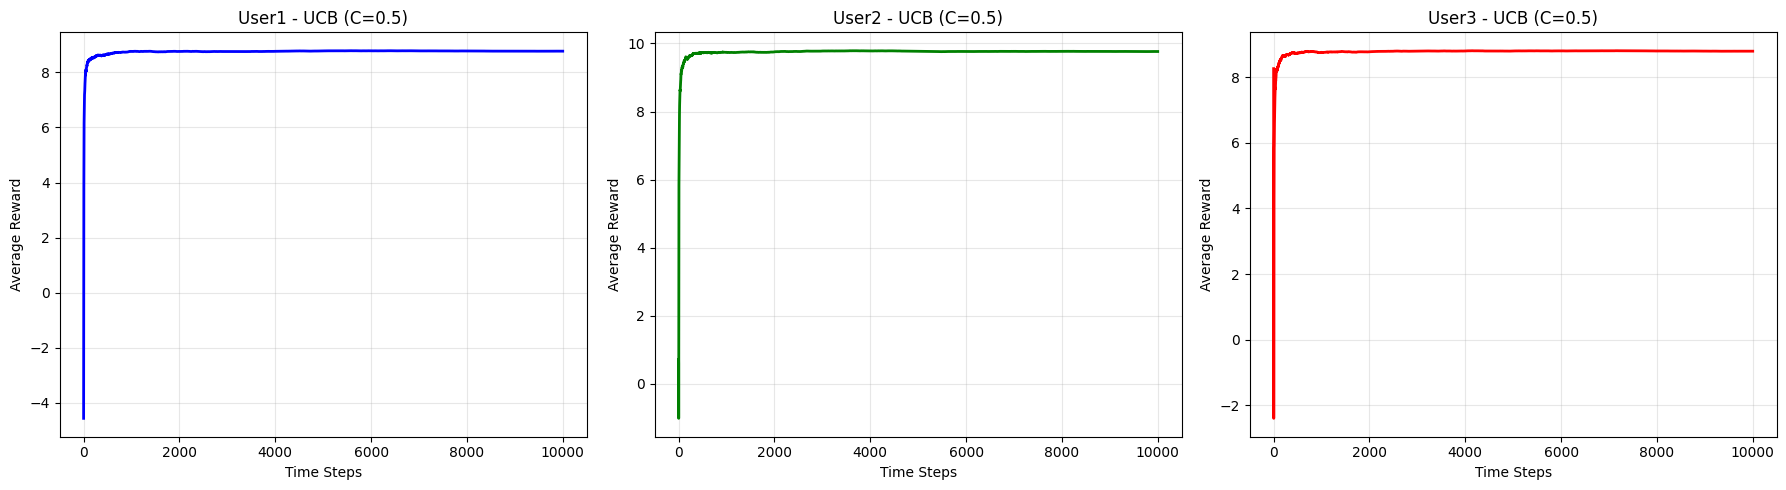

In [127]:
# Plot Average Reward vs Time for Each Context (UCB)
print("\n" + "="*70)
print("UCB: AVERAGE REWARD BY CONTEXT")
print("="*70)

# Retrain with best C but track per-context rewards
def train_ucb_per_context(c, T=10000):
    context_rewards = {ctx: [] for ctx in contexts}
    Q = {ctx: np.zeros(n_arms) for ctx in contexts}
    N = {ctx: np.zeros(n_arms) for ctx in contexts}

    for t in range(1, T + 1):
        for context in contexts:
            arm = ucb(context, c, Q, N, t)

            global_arm = get_arm_index(context, news_categories[arm])
            reward = reward_sampler.sample(global_arm)

            N[context][arm] += 1
            Q[context][arm] += (reward - Q[context][arm]) / N[context][arm]

            context_rewards[context].append(reward)
    
    # Calculate cumulative average for each context
    avg_rewards_per_context = {}
    for context in contexts:
        rewards = context_rewards[context]
        if len(rewards) > 0:
            avg_rewards_per_context[context] = np.cumsum(rewards) / np.arange(1, len(rewards) + 1)
        else:
            avg_rewards_per_context[context] = []
    
    return avg_rewards_per_context, Q, N

# Train with best C
context_rewards_ucb, _, _ = train_ucb_per_context(best_c)

# Plot separate graphs for each context
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'User1': 'blue', 'User2': 'green', 'User3': 'red'}

for idx, context in enumerate(contexts):
    if len(context_rewards_ucb[context]) > 0:
        axes[idx].plot(context_rewards_ucb[context], color=colors[context], linewidth=2)
        axes[idx].set_xlabel('Time Steps')
        axes[idx].set_ylabel('Average Reward')
        axes[idx].set_title(f'{context} - UCB (C={best_c})')
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [128]:
# Cell: SoftMax Implementation
import numpy as np
import random

def softmax(context, tau, Q):

    # Calculate softmax probabilities
    q_values = Q[context]
    exp_values = np.exp(q_values / tau)
    probabilities = exp_values / np.sum(exp_values)
    
    # Sample arm according to probabilities
    arm = np.random.choice(n_arms, p=probabilities)
    return arm


def train_softmax(tau=1.0, T=10000):
    rewards_over_time = []
    Q = {context: np.zeros(n_arms) for context in contexts}
    N = {context: np.zeros(n_arms) for context in contexts}
    
    for t in range(T):
        arm = softmax(context, tau, Q)
        
        # Get global arm index and sample reward
        global_arm = get_arm_index(context, news_categories[arm])
        reward = reward_sampler.sample(global_arm)
        
        # Update Q and N
        N[context][arm] += 1
        Q[context][arm] += (reward - Q[context][arm]) / N[context][arm]
        
        rewards_over_time.append(reward)
    
    return np.cumsum(rewards_over_time) / np.arange(1, T + 1), Q, N

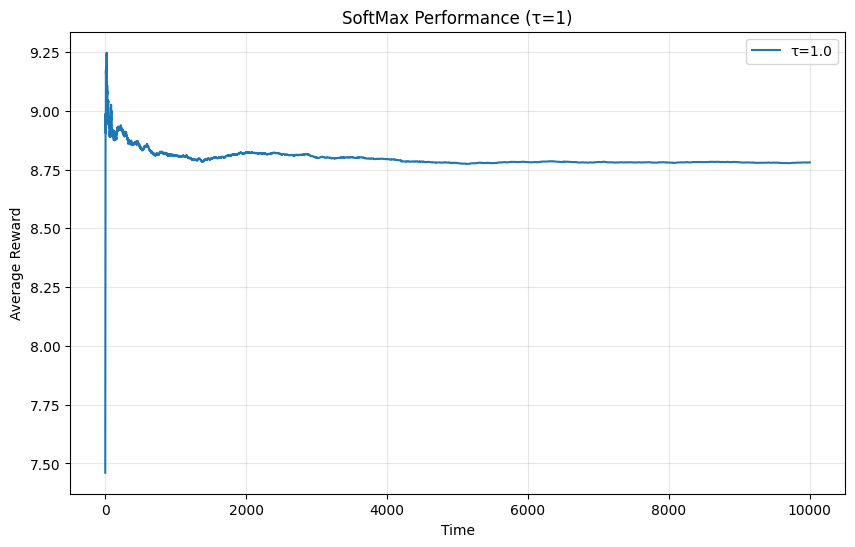

In [129]:
# Cell: Test SoftMax (tau=1 as per assignment)
tau = 1.0
softmax_avg_rewards, softmax_Q, softmax_N = train_softmax(tau=tau)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(softmax_avg_rewards, label=f"τ={tau}")
plt.xlabel("Time")
plt.ylabel("Average Reward")
plt.title("SoftMax Performance (τ=1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


SOFTMAX: AVERAGE REWARD BY CONTEXT


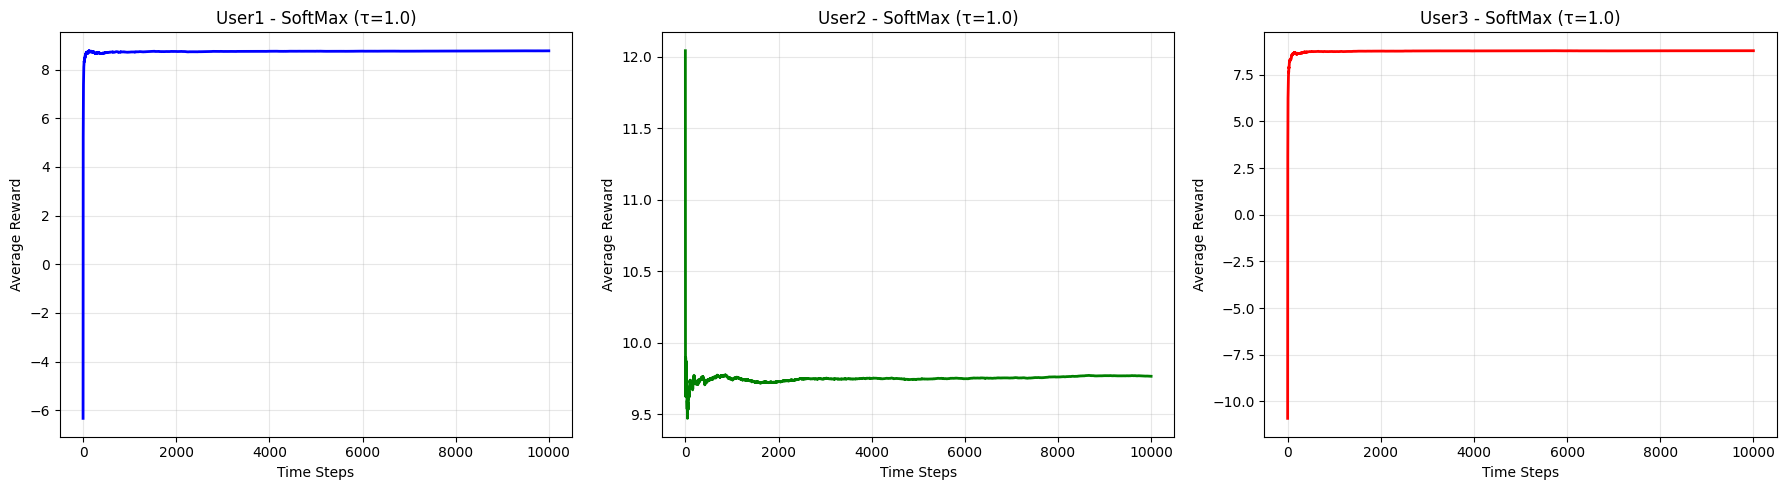

In [130]:
# Plot Average Reward vs Time for Each Context (SoftMax)
print("\n" + "="*70)
print("SOFTMAX: AVERAGE REWARD BY CONTEXT")
print("="*70)

def train_softmax_per_context(tau=1.0, T=10000):
    context_rewards = {ctx: [] for ctx in contexts}
    Q = {ctx: np.zeros(n_arms) for ctx in contexts}
    N = {ctx: np.zeros(n_arms) for ctx in contexts}

    for t in range(T):
        for context in contexts:
            arm = softmax(context, tau, Q)

            global_arm = get_arm_index(context, news_categories[arm])
            reward = reward_sampler.sample(global_arm)

            N[context][arm] += 1
            Q[context][arm] += (reward - Q[context][arm]) / N[context][arm]

            context_rewards[context].append(reward)
    
    avg_rewards_per_context = {}
    for context in contexts:
        rewards = context_rewards[context]
        if len(rewards) > 0:
            avg_rewards_per_context[context] = np.cumsum(rewards) / np.arange(1, len(rewards) + 1)
        else:
            avg_rewards_per_context[context] = []
    
    return avg_rewards_per_context, Q, N

context_rewards_softmax, _, _ = train_softmax_per_context(tau)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'User1': 'blue', 'User2': 'green', 'User3': 'red'}

for idx, context in enumerate(contexts):
    if len(context_rewards_softmax[context]) > 0:
        axes[idx].plot(context_rewards_softmax[context], color=colors[context], linewidth=2)
        axes[idx].set_xlabel('Time Steps')
        axes[idx].set_ylabel('Average Reward')
        axes[idx].set_title(f'{context} - SoftMax (τ={tau})')
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Algorithm Configuration   | Final Avg Reward
---------------------------------------------
ε-Greedy (ε=0.01)         | 8.691366        
UCB (C=0.5)               | 9.105894        🏆 WINNER
SoftMax (τ=1.0)           | 8.780269        


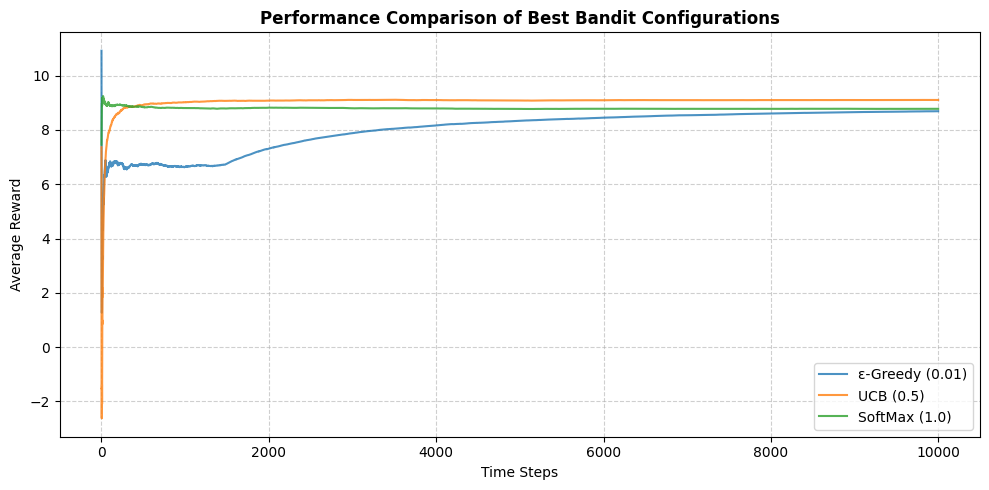


📝 Selecting UCB (C=0.5) Q-values for the recommendation engine...


In [131]:

best_eps = max(epsilon_results, key=lambda k: epsilon_results[k][-1])
best_c = max(ucb_results, key=lambda k: ucb_results[k][-1])

comparison = {
    f"ε-Greedy (ε={best_eps})": epsilon_results[best_eps][-1],
    f"UCB (C={best_c})": ucb_results[best_c][-1],
    f"SoftMax (τ={tau})": softmax_avg_rewards[-1]
}
winner = max(comparison, key=comparison.get)

# 3. Print Compact Results Table
print(f"\n{'Algorithm Configuration':<25} | {'Final Avg Reward':<15}")
print("-" * 45)
for algo, reward in comparison.items():
    marker = "🏆 WINNER" if algo == winner else ""
    print(f"{algo:<25} | {reward:<15.6f} {marker}")

# 4. Streamlined Plotting
plt.figure(figsize=(10, 5))
plt.plot(epsilon_results[best_eps], label=f"ε-Greedy ({best_eps})", alpha=0.8)
plt.plot(ucb_results[best_c], label=f"UCB ({best_c})", alpha=0.8)
plt.plot(softmax_avg_rewards, label=f"SoftMax ({tau})", alpha=0.8)

plt.title("Performance Comparison of Best Bandit Configurations", fontweight='bold')
plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 5. Extract Best Q-values for Recommendation Engine
print(f"\n📝 Selecting {winner} Q-values for the recommendation engine...")
if "ε-Greedy" in winner:
    _, best_Q, _ = train_epsilon_greedy(best_eps)
elif "UCB" in winner:
    _, best_Q, _ = train_ucb(best_c)
else:
    best_Q = softmax_Q

In [132]:
# Cell: Load and Preprocess Test Data
test_users = pd.read_csv("data/test_users.csv")

# Keep user_id for reference
test_user_ids = test_users['user_id'].copy()

# Drop user_id for processing
test_users_processed = test_users.drop(columns=["user_id", 'browser_version'])

# Handle missing values (same as training)
for col in test_users_processed.columns:
    if is_numeric_dtype(test_users_processed[col]):
        test_users_processed[col] = test_users_processed[col].fillna(
            test_users_processed[col].median()
        )
    else:
        test_users_processed[col] = test_users_processed[col].fillna(
            test_users_processed[col].mode()[0]
        )

# Encode categorical columns (using fitted encoder from training)
categorical_cols_test = test_users_processed.select_dtypes(
    include=["object", "string"]
).columns
test_users_processed[categorical_cols_test] = ordinal_encoder.transform(
    test_users_processed[categorical_cols_test]
)

# Scale features (using fitted scaler from training)
test_scaled = scaler.transform(test_users_processed)

print(f"Test users preprocessed: {test_scaled.shape}")

Test users preprocessed: (2000, 30)


In [133]:
# Debug: Check news articles structure
print("News Articles Columns:", news_articles.columns.tolist())
print("\nUnique categories in news:", news_articles['category'].unique())
print("\nSample news article:")
print(news_articles.iloc[0])
print("\nCategory counts:")
print(news_articles['category'].value_counts())

News Articles Columns: ['link', 'headline', 'category', 'short_description', 'authors', 'date']

Unique categories in news: <StringArray>
[     'U.S. NEWS',         'COMEDY',      'PARENTING',     'WORLD NEWS',
 'CULTURE & ARTS',           'TECH',         'SPORTS',  'ENTERTAINMENT',
       'POLITICS',     'WEIRD NEWS',    'ENVIRONMENT',      'EDUCATION',
          'CRIME',        'SCIENCE',       'WELLNESS',       'BUSINESS',
 'STYLE & BEAUTY',   'FOOD & DRINK',          'MEDIA',   'QUEER VOICES',
  'HOME & LIVING',          'WOMEN',   'BLACK VOICES',         'TRAVEL',
          'MONEY',       'RELIGION',  'LATINO VOICES',         'IMPACT',
       'WEDDINGS',        'COLLEGE',        'PARENTS', 'ARTS & CULTURE',
          'STYLE',          'GREEN',          'TASTE', 'HEALTHY LIVING',
  'THE WORLDPOST',      'GOOD NEWS',      'WORLDPOST',          'FIFTY',
           'ARTS',        'DIVORCE']
Length: 42, dtype: str

Sample news article:
link                 https://www.huffpost.com/entr

In [134]:
# Cell: Simple Recommendation System
def recommend_article(user_features_scaled, user_id):
    user_category_encoded = classifier.predict(user_features_scaled.reshape(1, -1))[0]
    user_category_label = target_encoder.inverse_transform([user_category_encoded])[0]
    

    context_mapping = {
        'user_1': 'User1',
        'user_2': 'User2',
        'user_3': 'User3'
    }
    context = context_mapping[user_category_label]
    

    best_arm = np.argmax(best_Q[context])
    news_category = news_categories[best_arm]
    

    category_articles = news_articles[news_articles['category'].str.lower() == news_category.lower()]
    
    if len(category_articles) > 0:
        sampled_article = category_articles.sample(n=1).iloc[0]
        article_title = sampled_article['headline']  
        article_id = sampled_article.name
    else:
        article_title = "No article available"
        article_id = None
    
    return {
        'user_id': user_id,
        'user_category': user_category_label,
        'context': context,
        'recommended_category': news_category,
        'arm_index': best_arm,
        'article_title': article_title,
        'article_id': article_id
    }


sample_rec = recommend_article(test_scaled[0], test_user_ids.iloc[0])
print("Sample Recommendation:")
print(f"  User ID: {sample_rec['user_id']}")
print(f"  Predicted Category: {sample_rec['user_category']}")
print(f"  Recommended News: {sample_rec['recommended_category']}")
print(f"  Article: {sample_rec['article_title'][:80]}...")

Sample Recommendation:
  User ID: U4058
  Predicted Category: user_2
  Recommended News: Crime
  Article: Investigators Piece Together Portrait Of Tashfeen Malik...


In [135]:

print("="*70)
print("GENERATING RECOMMENDATIONS FOR ALL TEST USERS")
print("="*70)

all_recommendations = []

for i in range(len(test_scaled)):
    rec = recommend_article(test_scaled[i], test_user_ids.iloc[i])
    all_recommendations.append(rec)

print(f"\n✓ Generated {len(all_recommendations)} recommendations")

recommendations_df = pd.DataFrame(all_recommendations)

output_df = recommendations_df[['user_id', 'user_category', 'recommended_category', 'article_title']].copy()
output_df.columns = ['User ID', 'Predicted User Category', 'Recommended News Category', 'Recommended Article']

print("\n" + "="*70)
print("FINAL RECOMMENDATIONS OUTPUT")
print("="*70)
print(output_df.head(10))

output_df.to_csv('final_recommendations.csv', index=False)

print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

print("\nPredicted User Categories Distribution:")
print(recommendations_df['user_category'].value_counts())

print("\nRecommended News Categories Distribution:")
print(recommendations_df['recommended_category'].value_counts())

print("\n" + "="*70)
print("ARTICLES RECOMMENDED PER USER COHORT")
print("="*70)
cross_tab = pd.crosstab(
    recommendations_df['user_category'], 
    recommendations_df['recommended_category'],
    margins=True,
    margins_name='Total'
)
print("\n", cross_tab)


GENERATING RECOMMENDATIONS FOR ALL TEST USERS

✓ Generated 2000 recommendations

FINAL RECOMMENDATIONS OUTPUT
  User ID Predicted User Category Recommended News Category  \
0   U4058                  user_2                     Crime   
1   U1118                  user_1                      Tech   
2   U6555                  user_1                      Tech   
3   U9170                  user_1                      Tech   
4   U3348                  user_1                      Tech   
5   U2244                  user_3             Entertainment   
6   U3022                  user_3             Entertainment   
7   U5291                  user_1                      Tech   
8   U1945                  user_3             Entertainment   
9   U6084                  user_3             Entertainment   

                                 Recommended Article  
0  Listen To Angry Woman Dial 911 Over Wrong Pizz...  
1                                 The Online Funeral  
2          The Top Laptop Deals